# Kolorování černobílých fotografií pomocí konvoluční neuronové sítě

**Workshop Machine Learning **
---

## 1. Úvod

### 1.1. Definice úlohy

Cílem je sestavit a natrénovat model strojového učení, který bude
schopen automaticky doplnit barvy do černobílých fotografií.


### 1.2. Omezení 

Vzhledem k tomu, že výpočet probíhá na notebooku bez výkonné GPU, byla
přijata následující rozhodnutí:

| Aspekt | Volba | Důvod |
|--------|-------|-------|
| Dataset | CIFAR-10 (32×32) | malé rozlišení, standardní akademická volba |
| Velikost podmnožiny | 5 000 train / 1 000 val / 1 000 test | rovnováha doba × učení |
| Architektura | mini U-Net (~1.9 M parametrů) | osvědčená pro image-to-image |
| Barevný prostor | CIE LAB | odděluje jas (L) od chromatičnosti (ab) |
| Optimalizátor | Adam + ReduceLROnPlateau | adaptivní lr s automatickým útlumem |
| Best-model checkpointing | ano | vrací epochu s nejlepší val. MSE |
| Framework | PyTorch | flexibilita, čitelnost |


## 2. Teoretický základ

### 2.1. Barevný prostor CIE LAB

Pro úlohu kolorizace se RGB prostor používá nevhodně, protože všechny tři
kanály obsahují směs jasu i barvy. Naproti tomu prostor **CIE LAB** zavádí:

- **L (lightness)** – přibližně logaritmovaná hodnota jasu, $L \in [0, 100]$,
- **a** – osa zelená ↔ červená, přibližně $a \in [-128, 127]$,
- **b** – osa modrá ↔ žlutá, přibližně $b \in [-128, 127]$.


### 2.2. Architektura U-Net

Použiji zjednodušenou variantu architektury **U-Net**.
Klíčové vlastnosti:

- **Enkodér** postupně redukuje prostorové rozlišení (32 → 16 → 8 → 4) a zvyšuje
  počet kanálů; zachytává tak sémantický kontext.
- **Dekodér** symetricky rekonstruuje prostorové rozlišení pomocí transponovaných
  konvolucí.
- **Skip-connections** přenášejí lokální detaily z enkodéru přímo do dekodéru,
  což je pro pixelovou úlohu nezbytné.

Inicializace vah: **Kaiming He** (vhodná pro ReLU nelinearitu).

### 2.3. Ztrátová funkce

Pro úlohu používám střední kvadratickou chybu (MSE) na ab-kanálech:

Minimum MSE odpovídá podmíněnému průměru, díky čemuž predikce inklinují k mírně vyšisovaným
(béžovo-šedým) barvám. Pro funkčnost projektu je to dostatečné a numericky stabilní.

### 2.4. Evaluační metriky

Trénovací ztráta (ab-MSE) sama o sobě je obtížně interpretovatelná, protože
běží v normalizovaném prostoru ab-kanálů. Proto vyhodnocení rozšiřujeme o:

- **RGB-MSE**: MSE po rekonstrukci $L + (a,b) \to \mathrm{RGB}$. Měří
  pixelovou chybu v lidsky pozorovatelném prostoru.
- **PSNR** (Peak Signal-to-Noise Ratio) v dB:

$$
\mathrm{PSNR} = 10 \log_{10}\frac{\mathrm{MAX}^2}{\mathrm{MSE}}
\;=\; -10 \log_{10}(\mathrm{RGB\text{-}MSE})
\quad (\text{pro } \mathrm{MAX}=1).
$$

PSNR je standardní metrika kvality obrazu; vyšší = věrnější rekonstrukce.


## 3. Konfigurace prostředí

V této sekci se importují všechny potřebné moduly, fixuje se seed pro
reprodukovatelnost a zjišťuje se, zda je k dispozici CUDA zařízení.


In [1]:
# Standardní knihovny
import random
from pathlib import Path

# Vědecký Python stack
import numpy as np
import torch
import matplotlib.pyplot as plt

# Vlastní moduly
from src import (
    ColorizationNet,
    get_dataloaders,
    train_model,
    evaluate_model,
    evaluate_rgb_metrics,
    show_sample_grid,
    plot_training_history,
    show_colorization_results,
)

# Reprodukovatelnost
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Použité zařízení: {DEVICE}")
print(f"Verze PyTorch:    {torch.__version__}")


Použité zařízení: cpu
Verze PyTorch:    2.12.1+cpu


## 4. Data

### 4.1. Dataset CIFAR-10

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) je standardní akademický
dataset obsahující 60 000 barevných obrázků o rozlišení 32×32 pixelů,
rozdělených do 10 tříd (letadlo, auto, pták, kočka, jelen, pes, žába, kůň,
loď, kamion). V této práci **třídy nepoužívám** – pracuji čistě s pixely.

### 4.2. Předzpracování

Konverze RGB → LAB je implementována v modulu `src/data_utils.py` pomocí
funkce `skimage.color.rgb2lab`. Aby trénink neopakoval konverzi v každé
iteraci, je celá podmnožina **převedena do LAB jednou** uvnitř
`get_dataloaders` a uložena jako `TensorDataset`. Při 5 000 trénovacích
vzorcích to spotřebuje cca 20 MB RAM, ale ušetří desítky sekund na epochu.

### 4.3. Rozdělení dat

| Část | Počet vzorků | Účel |
|------|--------------|------|
| Trénink | 5 000 | optimalizace vah |
| Validace | 1 000 | sledování overfittingu, výběr modelu |
| Test | 1 000 | finální zhodnocení |

Indexy jsou vybírány náhodně se zafixovaným seedem, tj. rozdělení je
reprodukovatelné. Pro reprodukovatelný shuffle v `DataLoader`u používám
explicitní `torch.Generator(seed)`.


In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    data_root="./data",
    n_train=5000,
    n_val=1000,
    n_test=1000,
    batch_size=32,
    num_workers=0,        # 0 = bezpečné na Windows a v Jupyteru
    seed=SEED,
)

print(f"Trénovacích dávek: {len(train_loader)}")
print(f"Validačních dávek: {len(val_loader)}")
print(f"Testovacích dávek: {len(test_loader)}")


Rozbaluji lokální archiv 'cifar-10-python.tar.gz' (bez stahování) ...
Předpočítávám LAB reprezentaci ...
Hotovo: train=5000, val=1000, test=1000
Trénovacích dávek: 157
Validačních dávek: 32
Testovacích dávek: 32


### 4.4. Vizuální kontrola dat

Před trénováním ověřím, že konverze RGB ↔ LAB pracuje korektně:
vykreslím několik vstupních L-kanálů (šedotónové) a jejich kompletní RGB
verze (cíl).


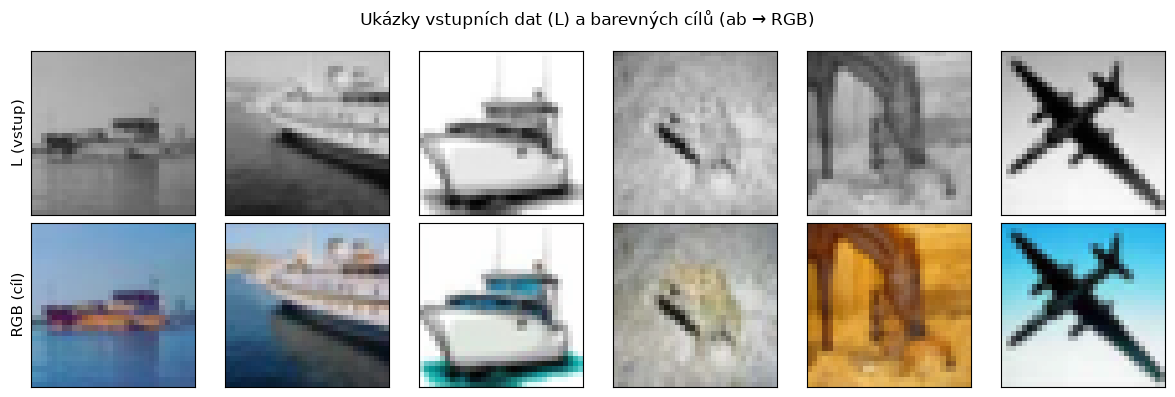

In [3]:
show_sample_grid(train_loader, n=6)


## 5. Model

### 5.1. Instanciace

Architektura je implementována v `src/model.py`. Parametr `base_channels`
škáluje počet kanálů ve všech vrstvách. Pro CIFAR-10 stačí `base_channels=32`.


In [5]:
model = ColorizationNet(base_channels=32).to(DEVICE)
print(model)
print(f"\nCelkový počet trénovatelných parametrů: {model.count_parameters():,}")


ColorizationNet(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(1

## 6. Trénování

### 6.1. Hyperparametry

| Parametr | Hodnota | Komentář |
|----------|---------|----------|
| Optimalizátor | Adam | adaptivní lr, robustní default |
| Počáteční learning rate | 1e-3 | standardní volba pro Adam |
| LR scheduler | ReduceLROnPlateau | factor=0.5, patience=3 epoch |
| Batch size | 32 | kompromis paměť/stabilita gradientu |
| Počet epoch | 20 | dle pozorování dostatečné na konvergenci |
| Loss | MSE | viz sekce 2.3 |
| Inicializace vah | Kaiming He | standard pro ReLU |
| Best-model checkpointing | ano | vrací epochu s nejnižší val. MSE |

### 6.2. Spuštění trénování

Funkce `train_model` provádí smyčku: trénink → validace v každé
epoše. Navíc:

- po každé epoše vyhodnotí validační ztrátu a uloží snapshot, pokud je
  lepší než dosavadní minimum (best-model checkpointing),
- pokud se validační ztráta `patience` epoch nezlepší, scheduler sníží
  learning rate o faktor 0.5,
- na konci obnoví do modelu váhy nejlepší epochy (in-place).


In [6]:
N_EPOCHS = 20
LEARNING_RATE = 1e-3

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=N_EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE,
    scheduler_patience=3,
    scheduler_factor=0.5,
    verbose=True,
)


Epoch 01/20 | train MSE: 0.0295 | val MSE: 0.0157 | lr: 1.0e-03 | 131.7s *
Epoch 02/20 | train MSE: 0.0147 | val MSE: 0.0138 | lr: 1.0e-03 | 76.7s *
Epoch 03/20 | train MSE: 0.0143 | val MSE: 0.0145 | lr: 1.0e-03 | 78.4s
Epoch 04/20 | train MSE: 0.0140 | val MSE: 0.0132 | lr: 1.0e-03 | 76.5s *
Epoch 05/20 | train MSE: 0.0137 | val MSE: 0.0133 | lr: 1.0e-03 | 69.4s
Epoch 06/20 | train MSE: 0.0134 | val MSE: 0.0137 | lr: 1.0e-03 | 73.7s
Epoch 07/20 | train MSE: 0.0133 | val MSE: 0.0127 | lr: 1.0e-03 | 100.1s *
Epoch 08/20 | train MSE: 0.0131 | val MSE: 0.0125 | lr: 1.0e-03 | 140.9s *
Epoch 09/20 | train MSE: 0.0130 | val MSE: 0.0125 | lr: 1.0e-03 | 72.6s
Epoch 10/20 | train MSE: 0.0130 | val MSE: 0.0129 | lr: 1.0e-03 | 79.0s
Epoch 11/20 | train MSE: 0.0128 | val MSE: 0.0123 | lr: 1.0e-03 | 139.1s *
Epoch 12/20 | train MSE: 0.0127 | val MSE: 0.0123 | lr: 1.0e-03 | 146.5s *
Epoch 13/20 | train MSE: 0.0127 | val MSE: 0.0127 | lr: 1.0e-03 | 76.0s
Epoch 14/20 | train MSE: 0.0125 | val MSE: 0.

### 6.3. Průběh trénování

Graf ukazuje vývoj trénovací a validační MSE a průběh learning rate. Pokud
by se křivky výrazně rozevřely (validační roste, trénovací klesá), šlo by
o overfitting. Svislá zelená čára značí epochu s nejlepší validační ztrátou.


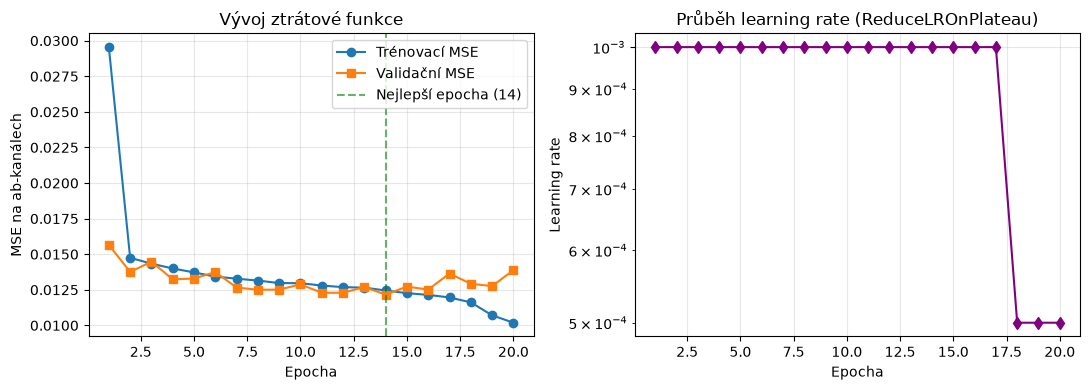

In [7]:
plot_training_history(history)


## 7. Vyhodnocení

### 7.1. Numerické metriky

Spočítám metriky na testovací sadě:

- **ab-MSE** – přímo na normalizovaných ab-kanálech (stejná jednotka jako loss),
- **RGB-MSE** – po rekonstrukci do RGB; měří chybu ve viditelném prostoru,
- **PSNR (dB)** – standardní metrika kvality obrazu, vyšší = lepší.


In [8]:
metrics = evaluate_rgb_metrics(model, test_loader, device=DEVICE)
print("Výsledky na testovací sadě:")
print(f"  ab-MSE:    {metrics['ab_mse']:.4f}")
print(f"  RGB-MSE:   {metrics['rgb_mse']:.4f}")
print(f"  RGB-PSNR:  {metrics['rgb_psnr_db']:.2f} dB")


Výsledky na testovací sadě:
  ab-MSE:    0.0125
  RGB-MSE:   0.0055
  RGB-PSNR:  22.58 dB


### 7.2. Vizuální vyhodnocení

Hlavním měřítkem úspěchu kolorizační úlohy je **subjektivní vizuální kvalita**.
Pro každý testovací vzorek porovnávám:

- **vstup** (L-kanál, šedé),
- **predikci** modelu (rekonstrukce RGB z L + predikovaných ab),
- **ground truth** (rekonstrukce RGB z L + skutečných ab).


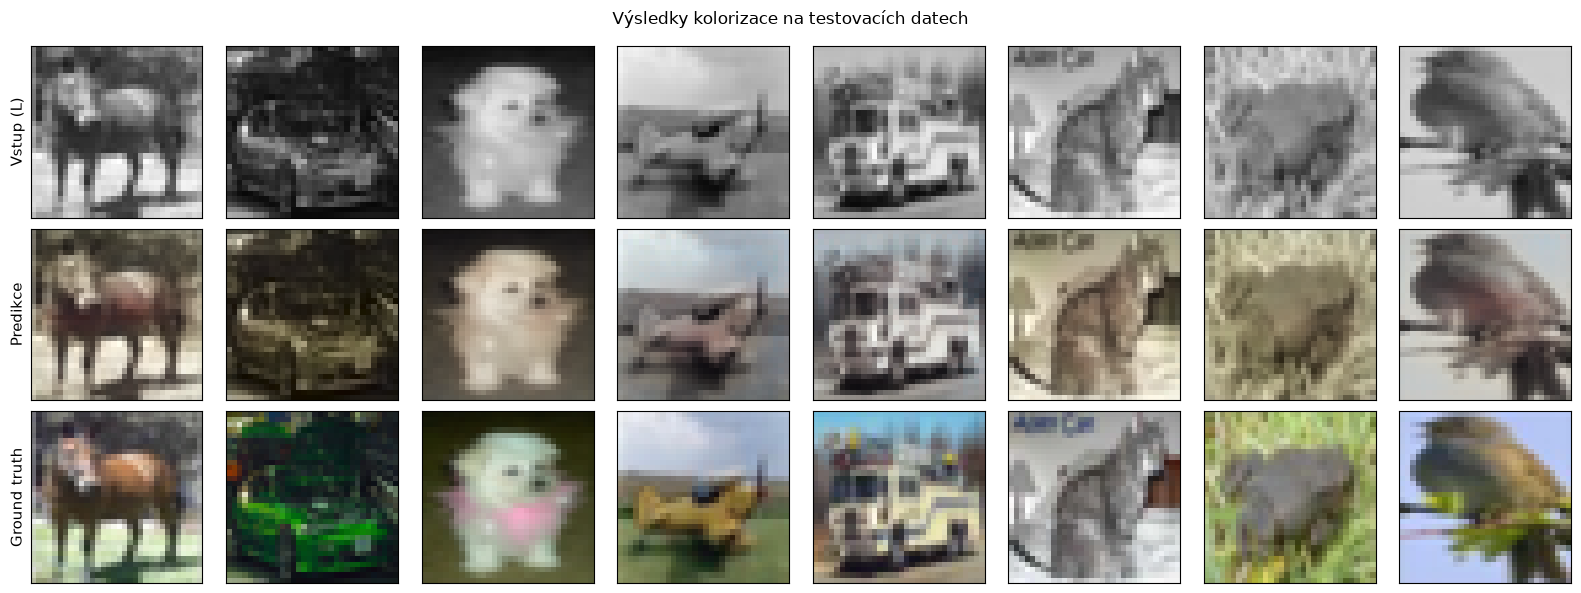

In [9]:
show_colorization_results(model, test_loader, n=8, device=DEVICE)


## 8. Diskuze

### 8.1. Interpretace výsledků

Po 20 epochách dosahuje model na testovací sadě řádu ab-MSE $\sim 10^{-2}$
a PSNR $\sim 20$–$25$ dB v RGB prostoru. Vizuálně síť:

- **úspěšně** rekonstruuje globální barevné tóny (modrá obloha, zelená vegetace,
  hnědé pozadí),
- **nevhodně interpretuje průměr** u objektů s vícero přípustnými barvami (auta, oblečení) –
  predikce jsou zbavené sytosti a barevnosti, jdou do šedo-béžova,
- **rozmazává** drobné barevné detaily, což odpovídá nízkému rozlišení 32×32
  a charakteru MSE loss.

### 8.2. Limity a možná rozšíření

- **Vyšší rozlišení** (64×64, 128×128) by si vyžádalo silnější GPU a delší trénink.
- **Alternativní formulace úlohy** jako klasifikace do diskrétních ab-binů
  systematicky zlepšuje sytost barev.
- **L1 ztrátová funkce** často poskytuje ostřejší výsledky než MSE
  (méně rozmazávání).
- **Perceptuální ztrátová funkce** (LPIPS, ztráta v prostoru features VGG)
  produkuje vizuálně přesvědčivější výsledky.
- **GAN-based kolorizace** (pix2pix, conditional GAN) generuje sytější barvy,
  za cenu vyšší ne-stability trénování.
- **Data augmentation** (horizontal flip, color jitter L-kanálu) by mohla
  pomoct generalizaci.

### 8.3. Reprodukovatelnost

Všechny náhodné komponenty (rozdělení datasetu, inicializace vah, shuffle
v DataLoaderu) byly seedovány hodnotou 42. Při shodné verzi PyTorch a shodném
zařízení (CPU vs. CUDA) by měly výsledky být reprodukovatelné na úrovni vah
modelu.

## 9. Závěr

Práce předvedla kompletní postup řešení úlohy automatické kolorizace fotografií
pomocí konvoluční neuronové sítě s architekturou U-Net. Byla zvolena
reprezentace v barevném prostoru CIE LAB, MSE ztrátová funkce a Adam
optimalizátor s adaptivním snižováním learning rate. Trénink používá
best-model checkpointing, takže výsledný model odpovídá epoše s nejlepší
validační metrikou, ne nutně poslední. Na datasetu CIFAR-10 (5 000 trénovacích
vzorků, 20 epoch) model dosahuje nízké MSE a vizuálně rozpoznatelné, byť
mírně ochuzené proti původu, kolorizace.Zároveň jsou identifikovány hlavní limity
zvoleného přístupu a navrhuje možné směry dalšího rozvoje.

